Parameter format not correct - "raw".


In [2]:
import pandas as pd

# Load dataset using absolute path (force it to work)
df = pd.read_csv(r"C:\Users\nidhi\Projects\customer-churn-analysis\data\telco_churn.csv")

# Show first 5 rows
df.head()


,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.40,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.00,Yes,Yes
2,3,51,Female,2,63.79,Month-to-Month,Fiber Optic,127.58,No,Yes
3,4,60,Female,8,102.34,One-Year,DSL,818.72,Yes,Yes
4,5,42,Male,32,69.01,Month-to-Month,NaN,2208.32,No,Yes


In [4]:
import pandas as pd

# Load the dataset
df = pd.read_csv(r"C:\Users\nidhi\Projects\customer-churn-analysis\data\telco_churn.csv")

# Display first 5 rows
df.head()



,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.40,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.00,Yes,Yes
2,3,51,Female,2,63.79,Month-to-Month,Fiber Optic,127.58,No,Yes
3,4,60,Female,8,102.34,One-Year,DSL,818.72,Yes,Yes
4,5,42,Male,32,69.01,Month-to-Month,NaN,2208.32,No,Yes


In [5]:
# Check general info
df.info()

# Check some statistics
df.describe()

# Check for missing values
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       1000 non-null   int64  
 1   Age              1000 non-null   int64  
 2   Gender           1000 non-null   object 
 3   Tenure           1000 non-null   int64  
 4   MonthlyCharges   1000 non-null   float64
 5   ContractType     1000 non-null   object 
 6   InternetService  703 non-null    object 
 7   TotalCharges     1000 non-null   float64
 8   TechSupport      1000 non-null   object 
 9   Churn            1000 non-null   object 
dtypes: float64(2), int64(3), object(5)
memory usage: 78.2+ KB


CustomerID           0
Age                  0
Gender               0
Tenure               0
MonthlyCharges       0
ContractType         0
InternetService    297
TotalCharges         0
TechSupport          0
Churn                0
dtype: int64

In [6]:
# 1️⃣ Drop irrelevant column
if 'customerID' in df.columns:
    df.drop('customerID', axis=1, inplace=True)

# 2️⃣ Convert TotalCharges to numeric (sometimes it's string)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# 3️⃣ Check for missing values
print("Missing values before dropping:", df.isnull().sum().sum())

# Drop rows with missing TotalCharges
df = df.dropna()

# 4️⃣ Encode target variable Churn (Yes=1, No=0)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# 5️⃣ Verify changes
print(df.info())
print(df.head())


Missing values before dropping: 297
<class 'pandas.core.frame.DataFrame'>
Index: 703 entries, 0 to 997
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       703 non-null    int64  
 1   Age              703 non-null    int64  
 2   Gender           703 non-null    object 
 3   Tenure           703 non-null    int64  
 4   MonthlyCharges   703 non-null    float64
 5   ContractType     703 non-null    object 
 6   InternetService  703 non-null    object 
 7   TotalCharges     703 non-null    float64
 8   TechSupport      703 non-null    object 
 9   Churn            703 non-null    int64  
dtypes: float64(2), int64(4), object(4)
memory usage: 60.4+ KB
None
   CustomerID  Age  Gender  Tenure  MonthlyCharges    ContractType  \
0           1   49    Male       4           88.35  Month-to-Month   
1           2   43    Male       0           36.67  Month-to-Month   
2           3   51  Female       2

In [8]:
!pip install seaborn



  Obtaining dependency information for seaborn from https://files.pythonhosted.org/packages/83/11/00d3c3dfc25ad54e731d91449895a79e4bf2384dc3ac01809010ba88f6d5/seaborn-0.13.2-py3-none-any.whl.metadata
   ---------------------------------------- 0.0/294.9 kB ? eta -:--:--
   - -------------------------------------- 10.2/294.9 kB ? eta -:--:--
   ---- ---------------------------------- 30.7/294.9 kB 435.7 kB/s eta 0:00:01
   ------------------------------------- -- 276.5/294.9 kB 2.4 MB/s eta 0:00:01
   ---------------------------------------- 294.9/294.9 kB 2.0 MB/s eta 0:00:00


In [10]:
# Show all column names exactly as Python sees them
print(df.columns.tolist())



['CustomerID', 'Age', 'Gender', 'Tenure', 'MonthlyCharges', 'ContractType', 'InternetService', 'TotalCharges', 'TechSupport', 'Churn']


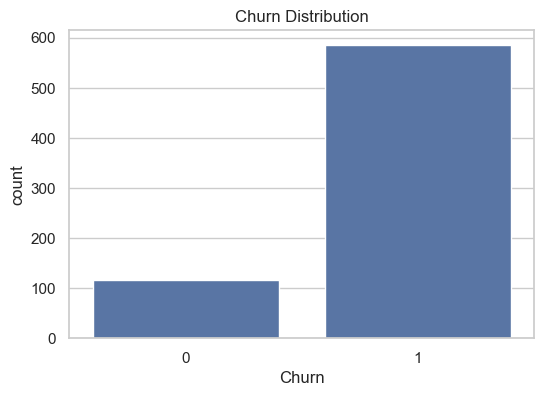

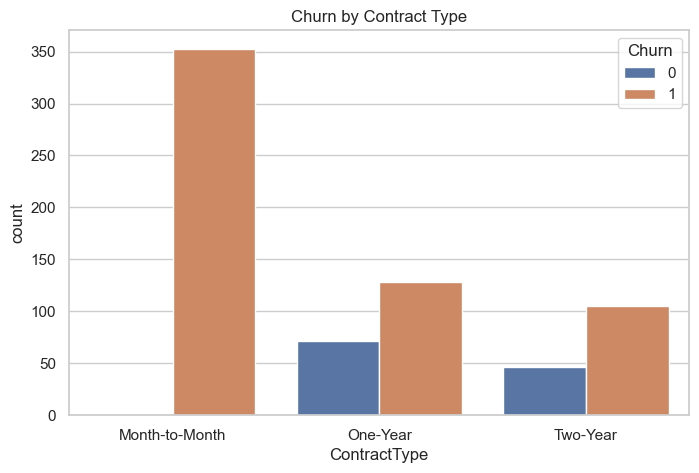

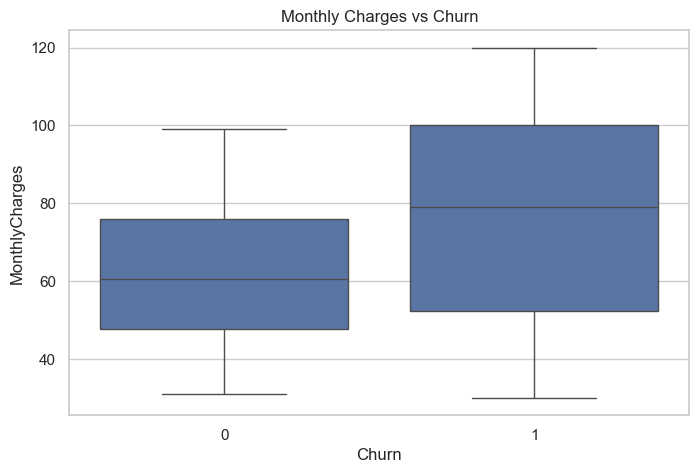

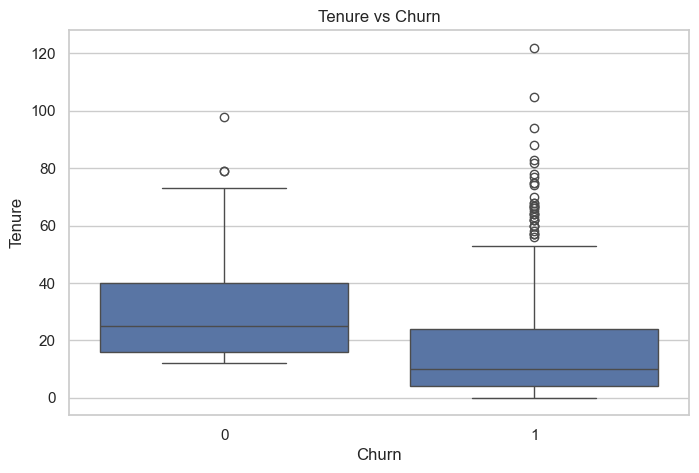

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set(style="whitegrid")

# 1️⃣ Churn distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

# 2️⃣ ContractType vs Churn
plt.figure(figsize=(8,5))
sns.countplot(x='ContractType', hue='Churn', data=df)
plt.title("Churn by Contract Type")
plt.show()

# 3️⃣ MonthlyCharges vs Churn
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

# 4️⃣ Tenure vs Churn
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn', y='Tenure', data=df)
plt.title("Tenure vs Churn")
plt.show()

# 5️⃣ Correlation heatmap (numeric



In [14]:
!pip install scikit-learn



In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Encode categorical columns
categorical_cols = ['Gender', 'ContractType', 'InternetService', 'TechSupport']
le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

# Separate features and target
X = df.drop('Churn', axis=1)
y = df['Churn']

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data prepared successfully!")
print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)


Data prepared successfully!
Training set shape: (562, 9)
Test set shape: (141, 9)


Accuracy: 0.900709219858156

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.50      0.61        22
           1       0.91      0.97      0.94       119

    accuracy                           0.90       141
   macro avg       0.85      0.74      0.78       141
weighted avg       0.89      0.90      0.89       141



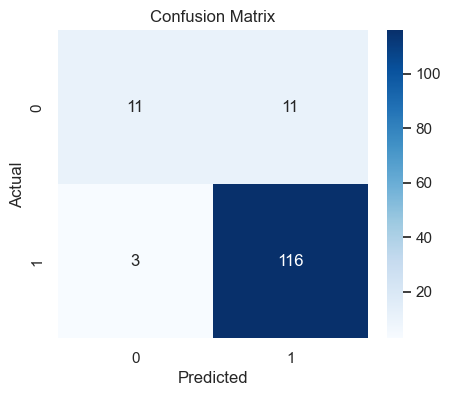

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Train Logistic Regression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


           Feature  Coefficient
2           Gender     0.120239
4   MonthlyCharges     0.014323
1              Age     0.005292
7     TotalCharges     0.000345
0       CustomerID    -0.000105
3           Tenure    -0.075153
6  InternetService    -0.117992
5     ContractType    -1.707444
8      TechSupport    -3.590328


C:\Users\nidhi\AppData\Local\Temp\ipykernel_8788\1071128417.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=feature_importance, palette="viridis")


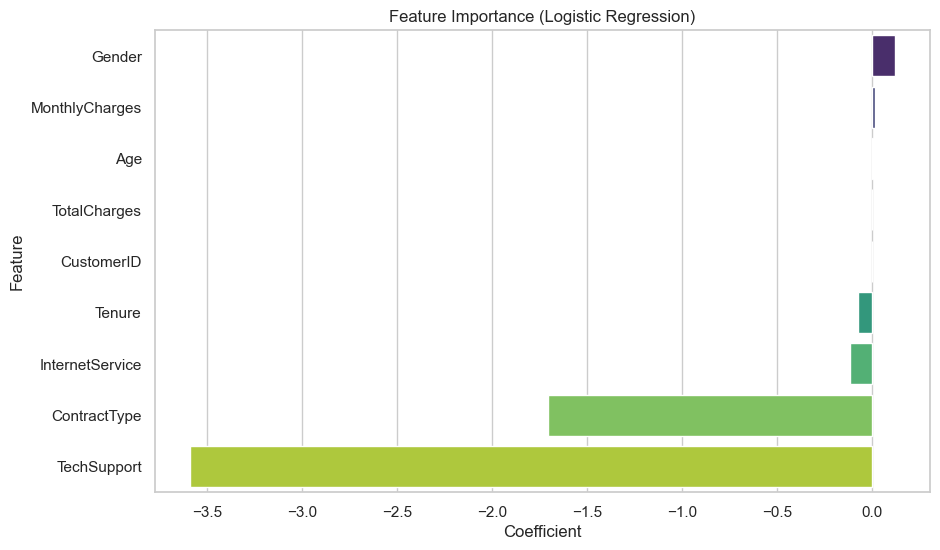

In [18]:
import pandas as pd

# Get feature importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

print(feature_importance)

# Plot feature importance
plt.figure(figsize=(10,6))
sns.barplot(x='Coefficient', y='Feature', data=feature_importance, palette="viridis")
plt.title("Feature Importance (Logistic Regression)")
plt.show()


Random Forest Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        22
           1       1.00      1.00      1.00       119

    accuracy                           1.00       141
   macro avg       1.00      1.00      1.00       141
weighted avg       1.00      1.00      1.00       141



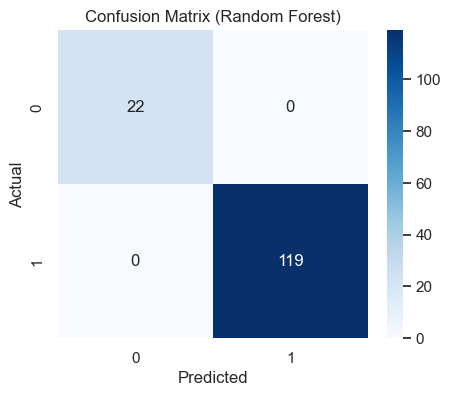

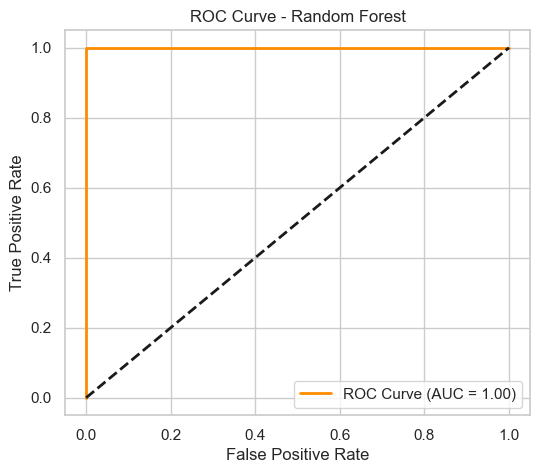

In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, roc_auc_score

# Initialize Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train
rf_model.fit(X_train, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:,1]  # probability for ROC

# Accuracy and classification report
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

# Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Random Forest)")
plt.show()

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba_rf)
roc_auc = roc_auc_score(y_test, y_proba_rf)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})', color='darkorange', linewidth=2)
plt.plot([0,1], [0,1], 'k--', lw=2)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend(loc="lower right")
plt.show()


In [1]:
import subprocess, sys, os
os.chdir(r"C:\Users\nidhi\Projects\customer-churn-analysis")

process = subprocess.Popen(
    [sys.executable, "-m", "streamlit", "run",
     r"C:\Users\nidhi\Projects\customer-churn-analysis\app.py",
     "--server.headless=true"],
)
print("Open http://localhost:8501")

Open http://localhost:8501


In [6]:
process.terminate()